In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import mu_0, epsilon_0
from scipy.special import ellipk

In [2]:
def calc_cpw_param_set(
    center_width: float, gap_width: float, substrate_r: float, metal_thickness: float
):
    a = center_width / 2
    b = center_width / 2 + gap_width
    d = metal_thickness / (2 * np.pi)

    u1 = (
        a
        + d / 2
        + 3 / 2 * np.log(2) * d
        - d / 2 * np.log(d / a)
        + d / 2 * np.log((b - a) / (a + b))
    )
    u2 = (
        b
        - d / 2
        - 3 / 2 * np.log(2) * d
        + d / 2 * np.log(d / a)
        + d / 2 * np.log((b - a) / (a + b))
    )
    k1 = u1 / u2
    k2 = np.sqrt(1 - k1**2)
    c = 2 * epsilon_0 * ellipk(k1) / ellipk(k2) * (1 + substrate_r)

    d = d/2
    u1 = a+d/2+3/2*np.log(2)*d-d/2*np.log(d/a)+d/2*np.log((b-a)/(a+b))
    u2 = b-d/2-3/2*np.log(2)*d+d/2*np.log(d/a)+d/2*np.log((b-a)/(a+b))
    k1 = u1/u2
    k2 = np.sqrt(1-k1**2)
    l = mu_0/4*ellipk(k2)/ellipk(k1)

    lambda_eff = 50e-9  # m, effective field penetration depth
    k = a/b
    g_ctr = 1/(4*a*ellipk(k)**2*(1-k)**2) * \
        (np.pi+np.log(4*np.pi*a/metal_thickness)-k*np.log((1+k)/(1-k)))
    g_gnd = 1/(4*a*ellipk(k)**2*(1-k)**2) * \
        (np.pi+np.log(4*np.pi*b/metal_thickness)-k*np.log((1+k)/(1-k)))
    g = g_ctr+g_gnd
    l_ki = g*mu_0*lambda_eff
    l_tot = l+l_ki

    return {'inductance': l_tot, 'capacitance': c}


def calc_target_length(target_frequency: float, cpw_param_set: dict):
    return 1e6*3 / (4 * target_frequency * np.sqrt(cpw_param_set['inductance'] * cpw_param_set['capacitance']))

In [3]:
def Z_coupling(Cc: float, omega: float):
    Z_cc = 1 / (1j * omega * Cc)
    return Z_cc 

def Z_open(Z0: float, length: float, beta: float):
    return -1j * Z0 / np.tan(beta * length)


def ABCD_component(Z: complex, Ad: bool = False):
    if Ad:
        return np.array([[1, 0], [1/Z, 1]])
    else:
        return np.array([[1, Z], [0, 1]])

def ABCD_line(Z0: float, length: float, beta: float):
    A = np.cos(beta * length)
    B = 1j * Z0 * np.sin(beta * length)
    C = 1j * np.sin(beta * length) / Z0
    D = np.cos(beta * length)
    return np.array([[A, B], [C, D]])

def ABCD_to_Y(ABCD: np.ndarray):
    A, B, C, D = ABCD.flatten()
    Y11 = D / B
    Y12 = (B * C - A * D) / B
    Y21 = -1 / B
    Y22 = A / B
    return np.array([[Y11, Y12], [Y21, Y22]])

def Y_to_S21(Y: np.ndarray, Z0: float):
    Y0 = 1 / Z0
    Y11, Y12, Y21, Y22 = Y.flatten()
    deltaY = (Y11 + Y0) * (Y22 + Y0) - Y12 * Y21
    S21 = (-2 * Y21 * Y0) / deltaY
    return S21

In [4]:
h = 6.626e-34
hbar = h/(2*np.pi)
phi_0 = 2.067e-15
E_j0 = 61.56e9 * h
E_c = 177.717e6 * h
d = 0.17

Z_0 = 50
C_c = 8.17e-15
C_T = 100.53e-15
N = 1000
w_r = 5.5e9*2*np.pi



resonator_widths = [7, 10, 7]

res_cpw_param_set = calc_cpw_param_set(
    center_width= resonator_widths[1]*1e-6, 
    gap_width=resonator_widths[0]*1e-6, 
    substrate_r=11.6, 
    metal_thickness=200e-9
)

l = calc_target_length(5.5e9, res_cpw_param_set)
l_f = l/1e6

l1 = l_f/4
l2 = (2*l_f)/3
l3 = l_f/12
l4 = l_f/2
l5 = l_f/4
l6 = l_f/4

In [5]:
phi_q1_values = np.linspace(-1, 1, N) * phi_0
phi_q2_values = np.linspace(-1, 1, N) * phi_0
S_21_vals = np.zeros((N,N), dtype=complex)
f_q1_vals = np.zeros(N)
f_q2_vals = np.zeros(N)

Z_open_1 = Z_open(Z_0, l3, w_r*np.sqrt(res_cpw_param_set['inductance'] * res_cpw_param_set['capacitance']))
ABCD_open_1 = ABCD_component(Z_open_1, Ad=True)
Z_open_2 = Z_open(Z_0, l4, w_r*np.sqrt(res_cpw_param_set['inductance'] * res_cpw_param_set['capacitance']))
ABCD_open_2 = ABCD_component(Z_open_2, Ad=True)
Z_coupling = Z_coupling(C_c, w_r)



Z_l1 = ABCD_line(Z_0, l1, w_r*np.sqrt(res_cpw_param_set['inductance'] * res_cpw_param_set['capacitance']))
Z_l2 = ABCD_line(Z_0, l2, w_r*np.sqrt(res_cpw_param_set['inductance'] * res_cpw_param_set['capacitance']))
Z_l5 = ABCD_line(Z_0, l5, w_r*np.sqrt(res_cpw_param_set['inductance'] * res_cpw_param_set['capacitance']))
Z_l6 = ABCD_line(Z_0, l6, w_r*np.sqrt(res_cpw_param_set['inductance'] * res_cpw_param_set['capacitance']))


for i1, phi_q1 in enumerate(phi_q1_values):
    E_j1 = E_j0 * np.abs(np.cos(np.pi * phi_q1 / phi_0)) * np.sqrt(1 + d**2 * np.tan(np.pi * phi_q1 / phi_0)**2)
    f_q1 = (np.sqrt(8*E_j1*E_c)-E_c)/h
    f_q1_vals[i1] = f_q1
    L_J1 = 1 / ((2 * np.pi * f_q1)**2 * C_T)
    Z_qubit_1 = np.sqrt(L_J1 / C_T)
    Z1 = Z_qubit_1 + 2*Z_coupling
    ABCD_qubit_1 = ABCD_component(Z1, Ad=False)
    ABCD_box_1 = Z_l1 @ ABCD_qubit_1 @ Z_l6
    Y_box_1 = ABCD_to_Y(ABCD_box_1)
    for i2, phi_q2 in enumerate(phi_q2_values):
        E_j2 = E_j0 * np.abs(np.cos(np.pi * phi_q2 / phi_0)) * np.sqrt(1 + d**2 * np.tan(np.pi * phi_q2 / phi_0)**2)
        f_q2 = (np.sqrt(8*E_j2*E_c)-E_c)/h
        L_J2 = 1 / ((2 * np.pi * f_q2)**2 * C_T)
        Z_qubit_2 = np.sqrt(L_J2 / C_T)
        f_q2_vals[i2] = f_q2
        Z2 = Z_qubit_2 + 2*Z_coupling
        ABCD_qubit_2 = ABCD_component(Z2, Ad=False)
        ABCD_box_2 = Z_l2 @ ABCD_open_1 @ ABCD_qubit_2 @ ABCD_open_2 @ Z_l5
        Y_box_2 = ABCD_to_Y(ABCD_box_2)
        Y_total = Y_box_1 + Y_box_2
        S_21_vals[i1, i2] = Y_to_S21(Y_total, Z_0)
        

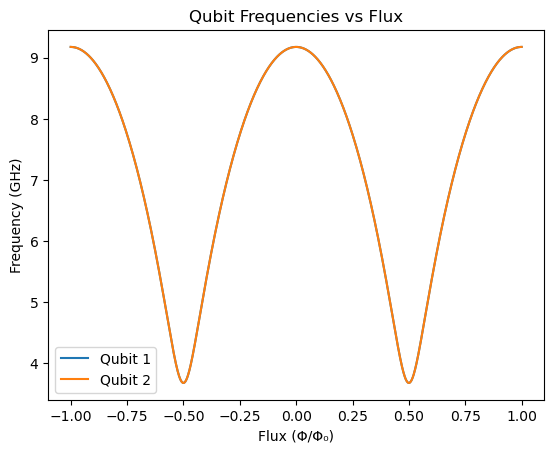

In [ ]:
# Check to see whether qubits cross the resonator frequency. Note; it does

plt.plot(phi_q1_values/phi_0, f_q1_vals/1e9, label='Qubit 1')
plt.plot(phi_q2_values/phi_0, f_q2_vals/1e9, label='Qubit 2')
plt.xlabel('Flux (Φ/Φ₀)')
plt.ylabel('Frequency (GHz)')
plt.title('Qubit Frequencies vs Flux')
plt.legend()
plt.show()

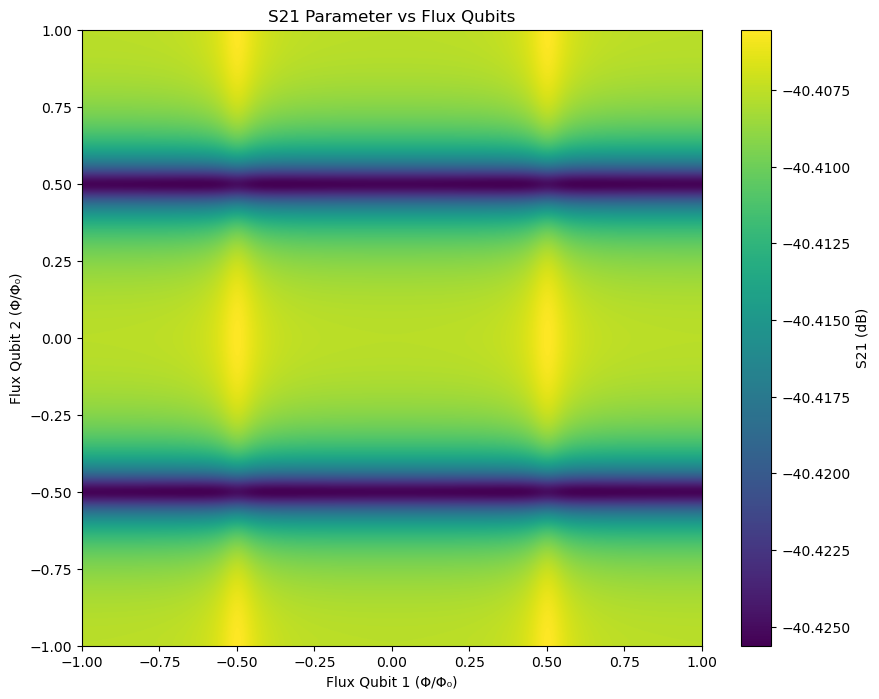

In [22]:
plt.figure(figsize=(10, 8))
plt.imshow(
    20 * np.log10(np.abs(S_21_vals)),
    extent=(-1, 1, -1, 1),
    origin='lower',
    aspect='auto',
    cmap='viridis'
)
plt.colorbar(label='S21 (dB)')
plt.xlabel('Flux Qubit 1 (Φ/Φ₀)')
plt.ylabel('Flux Qubit 2 (Φ/Φ₀)')
plt.title('S21 Parameter vs Flux Qubits')
plt.show()